# Bahraini Currency Classifier — Training

Trains a MobileNetV2 transfer-learning model on the `augmented/` folder and saves:
- `model.keras` — the trained model
- `class_names.json` — labels in output order
- `training_report.txt` — accuracy, per-class report, confusion matrix

Then `app.py` loads these and does the prediction.

## 1. Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


## 2. Configuration

In [2]:
DATA_DIR = Path("augmented")
MODEL_PATH = Path("model.keras")
LABELS_PATH = Path("class_names.json")
REPORT_PATH = Path("training_report.txt")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_HEAD = 8
EPOCHS_FINETUNE = 6
SEED = 42

## 3. Load datasets

Uses an 80/20 train/validation split from the `augmented/` folder — one subfolder per class.

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

class_names = train_ds.class_names
print(f"Classes ({len(class_names)}): {class_names}")

Found 1080 files belonging to 9 classes.
Using 864 files for training.
Found 1080 files belonging to 9 classes.
Using 216 files for validation.
Classes (9): ['100', '25', '5', '50', '500', 'Five', 'One', 'Ten', 'Twenty']


## 4. Preview a batch

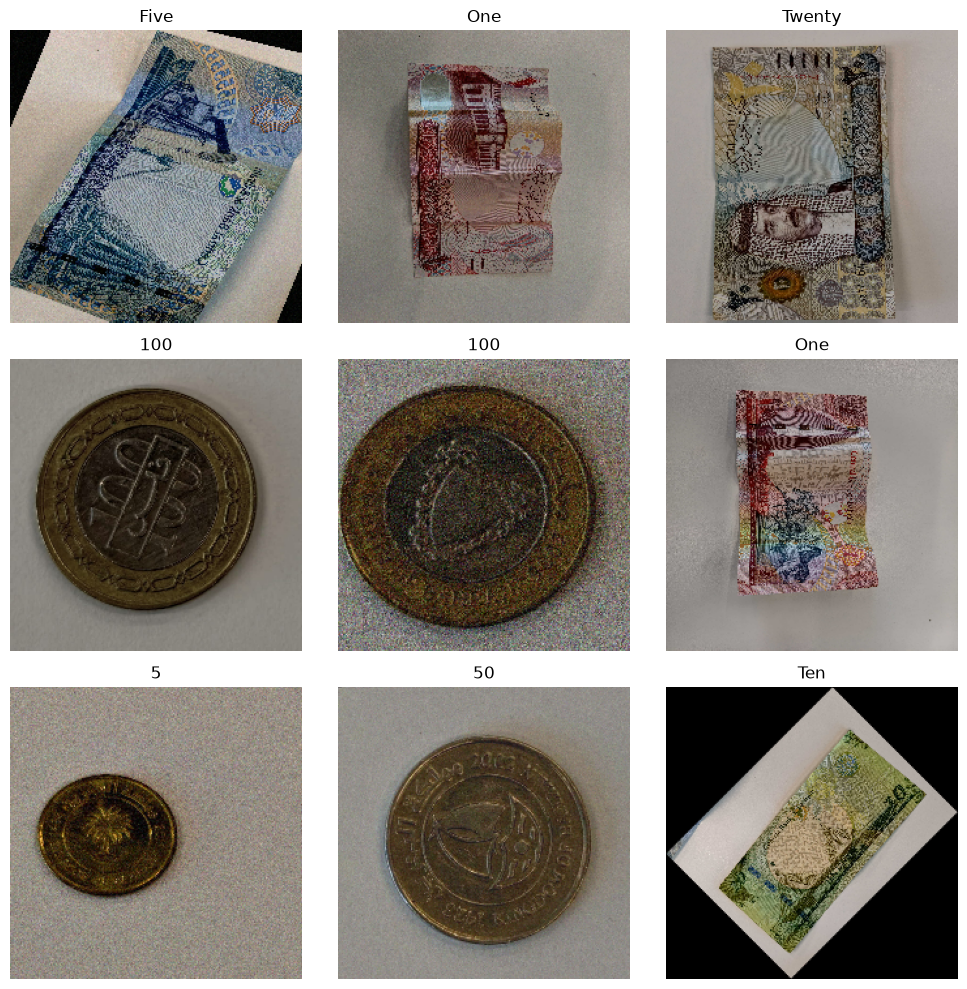

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Preprocess pipeline

MobileNetV2 expects pixels scaled to `[-1, 1]` — `preprocess_input` handles that.

In [6]:
preprocess = tf.keras.Sequential([layers.Lambda(preprocess_input)])

train_ds_p = (
    train_ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1000, seed=SEED)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds_p = (
    val_ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

## 6. Build the model

MobileNetV2 pretrained on ImageNet, frozen for stage 1. New classifier head on top.

In [7]:
base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = models.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 9)                   │          11,529 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Stage 1 — train the head only

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_head = model.fit(train_ds_p, validation_data=val_ds_p, epochs=EPOCHS_HEAD)

Epoch 1/8


C:\Users\Barho\miniconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 402ms/step - accuracy: 0.6250 - loss: 1.1306 - val_accuracy: 0.9213 - val_loss: 0.4775
Epoch 2/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 359ms/step - accuracy: 0.9201 - loss: 0.3358 - val_accuracy: 0.9722 - val_loss: 0.2317
Epoch 3/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 329ms/step - accuracy: 0.9583 - loss: 0.1919 - val_accuracy: 0.9537 - val_loss: 0.2241
Epoch 4/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 330ms/step - accuracy: 0.9745 - loss: 0.1353 - val_accuracy: 0.9676 - val_loss: 0.1534
Epoch 5/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 332ms/step - accuracy: 0.9815 - loss: 0.1076 - val_accuracy: 0.9861 - val_loss: 0.1071
Epoch 6/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 316ms/step - accuracy: 0.9838 - loss: 0.0859 - val_accuracy: 0.9907 - val_loss: 0.0791
Epoch 7/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 341ms/step - accuracy: 0.9907 - loss: 0.0636 - val_accuracy: 0.9954 - val_loss: 0.0670
Epoch 8/8
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 319ms/step - accuracy: 0.9931 - loss: 0.0564 - val_accuracy: 0.9907 - val

## 8. Stage 2 — fine-tune the top layers of the base

In [9]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model.fit(train_ds_p, validation_data=val_ds_p, epochs=EPOCHS_FINETUNE)

Epoch 1/6
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 420ms/step - accuracy: 0.9352 - loss: 0.2436 - val_accuracy: 0.9954 - val_loss: 0.0594
Epoch 2/6
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 403ms/step - accuracy: 0.9757 - loss: 0.1220 - val_accuracy: 0.9954 - val_loss: 0.0503
Epoch 3/6
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 438ms/step - accuracy: 0.9873 - loss: 0.0799 - val_accuracy: 0.9954 - val_loss: 0.0454
Epoch 4/6
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 408ms/step - accuracy: 0.9931 - loss: 0.0589 - val_accuracy: 0.9954 - val_loss: 0.0454
Epoch 5/6
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 397ms/step - accuracy: 0.9965 - loss: 0.0412 - val_accuracy: 0.9907 - val_loss: 0.0450
Epoch 6/6
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 404ms/step - accuracy: 0.9988 - loss: 0.0333 - val_accuracy: 0.9954 - val_loss: 0.0390


## 9. Plot training curves

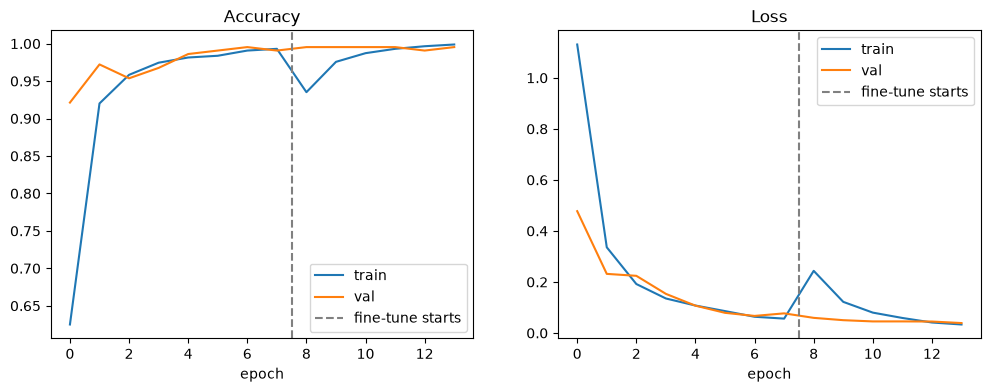

In [10]:
acc = history_head.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history_head.history["loss"] + history_ft.history["loss"]
val_loss = history_head.history["val_loss"] + history_ft.history["val_loss"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(acc, label="train")
ax1.plot(val_acc, label="val")
ax1.axvline(EPOCHS_HEAD - 0.5, color="gray", linestyle="--", label="fine-tune starts")
ax1.set_title("Accuracy")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(loss, label="train")
ax2.plot(val_loss, label="val")
ax2.axvline(EPOCHS_HEAD - 0.5, color="gray", linestyle="--", label="fine-tune starts")
ax2.set_title("Loss")
ax2.set_xlabel("epoch")
ax2.legend()
plt.show()

## 10. Evaluation — accuracy, per-class report, confusion matrix

In [13]:
val_loss_final, val_acc_final = model.evaluate(val_ds_p)
print(f"Validation accuracy: {val_acc_final:.4f}")

y_true, y_pred = [], []
for x, y in val_ds_p:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

print(f"Collected {len(y_true)} samples. Unique true labels: {sorted(set(y_true))}")

label_ids = list(range(len(class_names)))
report = classification_report(
    y_true, y_pred,
    labels=label_ids,
    target_names=class_names,
    digits=3,
    zero_division=0,
)
cm = confusion_matrix(y_true, y_pred, labels=label_ids)
print(report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.9954 - loss: 0.0390
Validation accuracy: 0.9954
Collected 216 samples. Unique true labels: [7, 8]
              precision    recall  f1-score   support

         100      0.000     0.000     0.000         0
          25      0.000     0.000     0.000         0
           5      0.000     0.000     0.000         0
          50      0.000     0.000     0.000         0
         500      0.000     0.000     0.000         0
        Five      0.000     0.000     0.000         0
         One      0.000     0.000     0.000         0
         Ten      1.000     1.000     1.000        96
      Twenty      1.000     0.992     0.996       120

    accuracy                          0.995       216
   macro avg      0.222     0.221     0.222       216
weighted avg      1.000     0.995     0.998       216



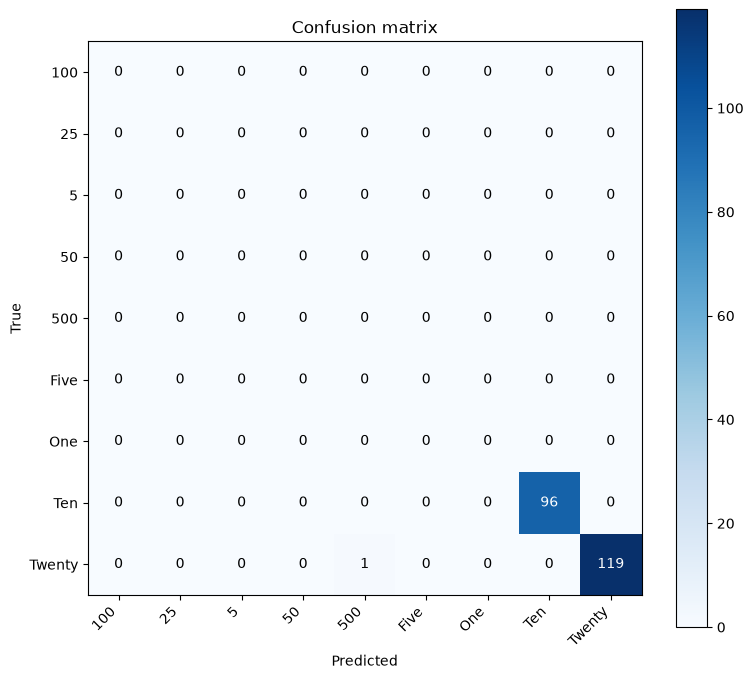

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 11. Save model, labels, and report

In [15]:
model.save(MODEL_PATH)
with open(LABELS_PATH, "w") as f:
    json.dump(class_names, f, indent=2)
with open(REPORT_PATH, "w") as f:
    f.write(f"Validation accuracy: {val_acc_final:.4f}\n\n")
    f.write("Classification report:\n")
    f.write(report + "\n\n")
    f.write("Confusion matrix (rows=true, cols=pred):\n")
    f.write("Labels: " + ", ".join(class_names) + "\n")
    f.write(np.array2string(cm))

print(f"Saved model    -> {MODEL_PATH}")
print(f"Saved labels   -> {LABELS_PATH}")
print(f"Saved report   -> {REPORT_PATH}")
print("\nDone. Now run:  streamlit run app.py")

Saved model    -> model.keras
Saved labels   -> class_names.json
Saved report   -> training_report.txt

Done. Now run:  streamlit run app.py
